# 03 - Análise exploratória (EDA)

Notebook responsável pela análise exploratória dos dados limpos em
`data/processed/`: estatísticas descritivas, correlações entre variáveis
climáticas e produção cafeeira, e geração de gráficos exploratórios
(salvos em `figuras/`).

Usa as funções de `src/risco.py`.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/lavras_clima_limpo.csv")
df.shape

(9132, 4)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9132 entries, 0 to 9131
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                9132 non-null   str    
 1   temperature_2m_max  9132 non-null   float64
 2   temperature_2m_min  9132 non-null   float64
 3   precipitation_sum   9132 non-null   float64
dtypes: float64(3), str(1)
memory usage: 374.7 KB


In [3]:
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2000-01-01,21.5,18.7,37.7
1,2000-01-02,20.0,18.8,33.4
2,2000-01-03,21.3,18.4,44.9
3,2000-01-04,20.7,17.9,13.4
4,2000-01-05,26.4,17.1,1.1


In [4]:
df.tail()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
9127,2024-12-27,22.4,19.1,24.9
9128,2024-12-28,25.7,18.3,12.9
9129,2024-12-29,24.3,17.8,28.7
9130,2024-12-30,26.3,17.4,8.8
9131,2024-12-31,26.4,16.5,6.3


In [5]:
df.describe()

,temperature_2m_max,temperature_2m_min,precipitation_sum
count,9132.000000,9132.000000,9132.000000
mean,25.311947,15.465703,3.203887
std,2.929169,3.141925,6.717872
min,14.300000,3.100000,0.000000
25%,23.400000,13.200000,0.000000
50%,25.500000,16.200000,0.100000
75%,27.300000,18.000000,3.400000
max,36.400000,22.100000,90.600000


## Observações iniciais

1. **Temperatura mínima tem uma cauda fria acentuada**: a média da mínima
   diária é ~15,5 °C (plausível para Lavras, que fica a ~900 m de
   altitude), mas o valor mínimo absoluto é 3,1 °C — indício de eventos
   de geada, relevantes para risco na cafeicultura.
2. **Chuva é muito assimétrica (skewed)**: a mediana de precipitação
   diária é de apenas 0,1 mm, bem abaixo da média de 3,2 mm, e o máximo
   chega a 90,6 mm em um único dia. Isso mostra que a maior parte dos
   dias é seca, com poucos eventos de chuva intensa puxando a média
   para cima — típico do regime de chuvas concentradas em Lavras.

## Índices de risco climático

Usando as funções de `src/risco.py`, calculamos indicadores de risco relevantes para a cafeicultura: dias de geada (leve/severa), dias de chuva excessiva e ocorrências de veranico (sequência de dias secos dentro da estação chuvosa, out-mar).

In [6]:
import sys
sys.path.append("..")

from src.risco import resumo_anual_risco, contar_sequencias_secas

df["time"] = pd.to_datetime(df["time"])

In [7]:
resumo = resumo_anual_risco(df)
resumo

,geada_leve,geada_severa,chuva_excessiva
ano,,,
2000,0,0,1
2001,0,0,0
2002,0,0,1
2003,0,0,0
2004,0,0,1
2005,0,0,0
2006,0,0,0
2007,0,0,1
2008,0,0,2


**Nota sobre geada**: com o limiar de geada leve (≤3°C), nenhum dia da série é classificado — a mínima absoluta observada na base é 3,1°C. Isso sugere uma limitação da fonte Open-Meteo (dado de modelo/reanálise em grade, não estação terrestre local), que tende a suavizar extremos. Para detectar geadas de fato, provavelmente será necessário complementar com dados de estação (ex.: INMET) em uma iteração futura.

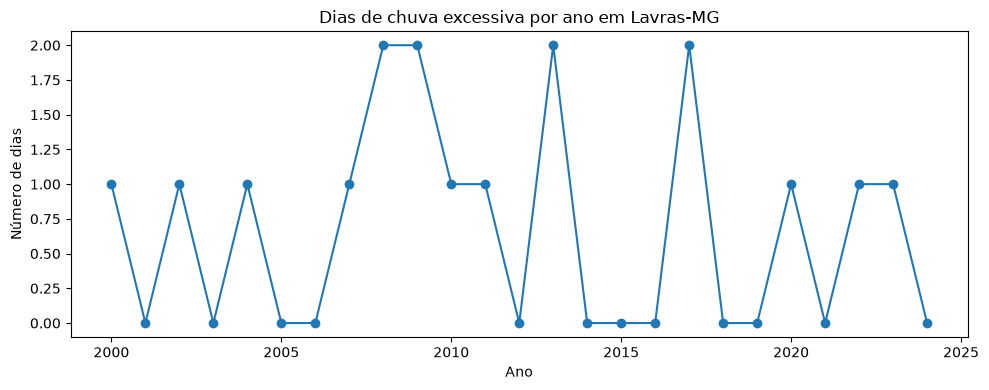

In [8]:
import matplotlib.pyplot as plt

resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.savefig("../figuras/chuva_excessiva_por_ano.png", dpi=150)
plt.show()

### Veranicos

Sequências de pelo menos 10 dias secos consecutivos ocorrendo dentro da estação chuvosa (outubro a março), quando a planta espera chuva regular.

In [9]:
veranicos = contar_sequencias_secas(df)
print("Veranicos detectados:", len(veranicos))
veranicos

Veranicos detectados: 30


,inicio,fim,duracao
0,2000-10-07,2000-10-20,14
1,2001-02-17,2001-03-02,14
2,2002-03-28,2002-04-06,10
3,2002-10-02,2002-10-17,16
4,2003-02-03,2003-02-14,12
5,2003-10-12,2003-10-21,10
6,2005-03-26,2005-04-05,11
7,2005-10-08,2005-10-18,11
8,2006-01-09,2006-01-25,17
9,2007-02-28,2007-03-16,17
